Import python modules

In [1]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
import lzma

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')

Read in alignment

In [2]:
# Use biopython to read the fasta file in xz format
fasta_file = '../results/aligned.H7N9.HA.fa.xz'
with lzma.open(fasta_file, 'rt') as f:
    records = list(SeqIO.parse(f, 'fasta'))

# Now you can work with the records
print(f"Loaded {len(records)} sequences")

Loaded 3070 sequences


Slice the alignment to only include the CDS of the reference sequence.

In [3]:
# Define the start and end positions of the gene of interest
gene_start = 1
gene_end = 1683

# For each record, slice the sequence and create a new SeqRecord
def slice_record(record):
    
    # Slice the sequence
    sliced_seq = record.seq[gene_start-1:gene_end]
    
    # Create a new SeqRecord with the sliced sequence
    new_record = SeqRecord(
        Seq(sliced_seq),
        id=record.id,
        description=record.description
    )
    return new_record

# Create a list of sliced records
sliced_records = [slice_record(record) for record in records]

Get a list of ambiguous characters (i.e., characters that are not A, T, G, C, or -)

In [4]:
# Make a list of unique characters in the sliced sequences
unique_characters = set()
for record in sliced_records:
    unique_characters.update(set(record.seq))
print(f"Unique characters in the sliced sequences: {unique_characters}")

# Make a set of ambiguous characters that are not A, C, G, T, or -
unambiguous_characters = set("ACGT-")
ambiguous_characters = unique_characters - unambiguous_characters
print(f"Ambiguous characters: {ambiguous_characters}")

Unique characters in the sliced sequences: {'R', 'Y', 'N', 'T', 'A', 'C', 'M', 'G', 'S', '-', 'W', 'K', 'D'}
Ambiguous characters: {'S', 'D', 'Y', 'R', 'W', 'N', 'K', 'M'}


Compute stats of each sequence in the alignment

In [5]:
# Make a dataframe that reports for each record:
# 1. The length of the sequence
# 2. The number of gaps
# 3. The number of ambiguous bases
# 4. The percent identity to the first record
def analyze_record(record):
    seq = record.seq
    length = len(seq)
    num_gaps = seq.count('-')
    num_ambiguous = 0
    for char in ambiguous_characters:
        num_ambiguous += seq.count(char)
    percent_identity = sum([i == j for (i, j) in zip(seq, ref_seq)]) / length * 100
    return {
        'id': record.id,
        'length': length,
        'frac_gaps': num_gaps/length,
        'frac_ambiguous': num_ambiguous/length,
        'percent_identity': percent_identity
    }

# Create a DataFrame with the above info
ref_seq = sliced_records[0].seq
analysis_results = [analyze_record(record) for record in sliced_records]
df = pd.DataFrame(analysis_results)

Plot cumulative density plots for metrics from above

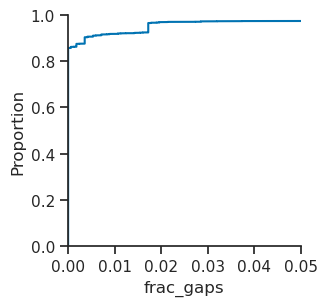

In [6]:
plt.figure(figsize=[3,3])
sns.ecdfplot(x='frac_gaps', data=df)
plt.xlim([0, 0.05])
sns.despine()
plt.show()

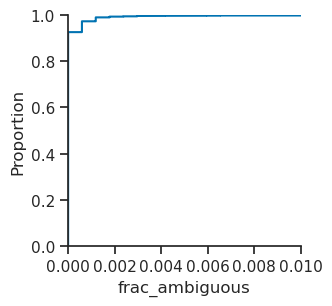

In [7]:
plt.figure(figsize=[3,3])
sns.ecdfplot(x='frac_ambiguous', data=df)
plt.xlim([0, 0.01])
sns.despine()
plt.show()

Filter out sequences based on the fraction of characters that are gaps or ambiguous nucleotides. Then, write a new fasta file with the sliced and filtered sequences.

In [8]:
# Filter out sequences with too many gaps or ambiguous bases
curated_df = df[(df['frac_gaps'] < 0.05) & (df['frac_ambiguous'] < 0.01)]

# Save the curated sequences to a new fasta file
curated_records = [record for record in sliced_records if record.id in curated_df['id'].values]
curated_fasta_file = '../results/curated_sequences.fasta.xz'
with lzma.open(curated_fasta_file, 'wt') as f:  # 'wt' for write text mode
    SeqIO.write(curated_records, f, 'fasta')
print(f"Saved curated sequences to {curated_fasta_file}")

Saved curated sequences to ../results/curated_sequences.fasta.xz


Plot the cumulative density of percent identity to the reference sequence

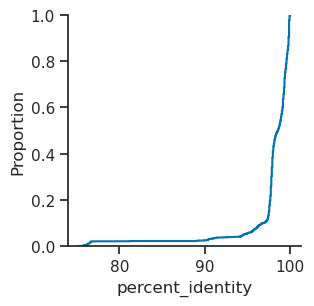

In [9]:
plt.figure(figsize=[3,3])
sns.ecdfplot(x='percent_identity', data=curated_df)
sns.despine()
plt.show()

In [10]:
curated_df.sort_values('percent_identity').iloc[0]['id']

'EPI3337847|HA|A/cinnamon_teal/Chile/C37724/2018|EPI_ISL_19167903|A_/_H7N9'